# Phase 4 — HAR-RV Forecasting and HAR-Based VRP Inspection

This notebook inspects Phase 4 outputs only.

It loads:
- HAR forecast panels
- HAR-VRP panels
- forecast accuracy table
- coefficient history
- no-lookahead audit table
- metadata

It does not:
- fit HAR models
- generate production outputs
- tune parameters
- create regimes
- create trading signals
- run backtests

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


cwd = Path.cwd()

if cwd.name == "notebooks":
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd

DATA_DIR = PROJECT_ROOT / "data" / "processed"
REPORT_TABLE_DIR = PROJECT_ROOT / "reports" / "tables"
REPORT_FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

print("PROJECT_ROOT:", PROJECT_ROOT)

PROJECT_ROOT: c:\Users\daksh\Desktop\EPAT\EPAT_Project_VRP_Regime


In [2]:
us_har = pd.read_parquet(DATA_DIR / "us_har_forecast.parquet")
india_har = pd.read_parquet(DATA_DIR / "india_har_forecast.parquet")

us_vrp_har = pd.read_parquet(DATA_DIR / "us_vrp_har.parquet")
india_vrp_har = pd.read_parquet(DATA_DIR / "india_vrp_har.parquet")

accuracy = pd.read_csv(REPORT_TABLE_DIR / "har_forecast_accuracy.csv")
coefficients = pd.read_csv(REPORT_TABLE_DIR / "har_coefficients.csv")
audit = pd.read_csv(REPORT_TABLE_DIR / "har_no_lookahead_audit.csv")
metadata_path = REPORT_TABLE_DIR / "har_metadata.json"

print("US HAR:", us_har.shape)
print("India HAR:", india_har.shape)
print("US HAR-VRP:", us_vrp_har.shape)
print("India HAR-VRP:", india_vrp_har.shape)
print("Accuracy:", accuracy.shape)
print("Coefficients:", coefficients.shape)
print("Audit:", audit.shape)
print("Metadata exists:", metadata_path.exists())

US HAR: (9156, 20)
India HAR: (4204, 20)
US HAR-VRP: (9156, 42)
India HAR-VRP: (4204, 42)
Accuracy: (8, 11)
Coefficients: (12228, 20)
Audit: (13360, 11)
Metadata exists: True


In [3]:
HAR_FORECAST_REQUIRED = [
    "date",
    "market",
    "target_col",
    "target_start_date",
    "target_end_date",
    "rv_gk_22d_forward_ann_label",
    "har_rv_d_lag1_ann",
    "har_rv_w_lag1_ann",
    "har_rv_m_lag1_ann",
    "naive_lagged_22d_rv_ann",
    "expanding_mean_forward_rv_baseline",
    "rolling_mean_forward_rv_baseline",
    "har_rv_gk_22d_forecast_ann",
    "har_model_name",
    "har_train_start_date",
    "har_train_end_date",
    "har_n_train",
    "har_oos_flag",
    "har_forecast_available",
    "har_blocked_reason",
]

VRP_HAR_REQUIRED = [
    "date",
    "market",
    "iv_ann",
    "har_rv_gk_22d_forecast_ann",
    "har_forecast_available",
    "har_blocked_reason",
    "vrp_har_gk",
    "vrp_har_gk_positive",
]

for name, df, required in [
    ("us_har", us_har, HAR_FORECAST_REQUIRED),
    ("india_har", india_har, HAR_FORECAST_REQUIRED),
    ("us_vrp_har", us_vrp_har, VRP_HAR_REQUIRED),
    ("india_vrp_har", india_vrp_har, VRP_HAR_REQUIRED),
]:
    missing = [col for col in required if col not in df.columns]
    print(name, "missing:", missing)
    assert not missing

us_har missing: []
india_har missing: []
us_vrp_har missing: []
india_vrp_har missing: []


In [4]:
def forecast_status_summary(df: pd.DataFrame, market: str) -> pd.DataFrame:
    out = (
        df["har_blocked_reason"]
        .fillna("available")
        .value_counts(dropna=False)
        .rename_axis("status")
        .reset_index(name="count")
    )
    out["market"] = market
    out["share"] = out["count"] / len(df)
    return out[["market", "status", "count", "share"]]


status_summary = pd.concat(
    [
        forecast_status_summary(us_har, "US"),
        forecast_status_summary(india_har, "INDIA"),
    ],
    ignore_index=True,
)

status_summary

,market,status,count,share
0,US,available,8590,0.938183
1,US,insufficient_training_history,544,0.059415
2,US,missing_target_metadata,22,0.002403
3,INDIA,available,3638,0.865366
4,INDIA,insufficient_training_history,544,0.129401
5,INDIA,missing_target_metadata,22,0.005233


In [5]:
audit_check = audit.copy()

available = audit_check[audit_check["forecast_available"].astype(bool)].copy()

available["forecast_date"] = pd.to_datetime(available["forecast_date"])
available["max_training_target_end_date"] = pd.to_datetime(
    available["max_training_target_end_date"]
)

bad = available[
    available["max_training_target_end_date"] >= available["forecast_date"]
]

print("Available audit rows:", len(available))
print("Bad audit rows:", len(bad))

assert bad.empty
assert available["rule_target_end_before_forecast_date"].astype(bool).all()

available.head()

Available audit rows: 12228
Bad audit rows: 0


,market,forecast_date,n_candidate_train_rows,n_valid_train_rows,min_train_required,max_training_row_date,max_training_target_end_date,forecast_date_minus_max_target_end_days,rule_target_end_before_forecast_date,forecast_available,blocked_reason
544,US,1992-02-27,544,500,500,1992-01-24,1992-02-26,1.0,True,True,NaN
545,US,1992-02-28,545,501,500,1992-01-27,1992-02-27,1.0,True,True,NaN
546,US,1992-03-02,546,502,500,1992-01-28,1992-02-28,3.0,True,True,NaN
547,US,1992-03-03,547,503,500,1992-01-29,1992-03-02,1.0,True,True,NaN
548,US,1992-03-04,548,504,500,1992-01-30,1992-03-03,1.0,True,True,NaN


In [6]:
accuracy

,market,forecast_col,target_col,n_obs,mse,rmse,mae,qlike,bias,correlation,directional_accuracy_vs_baseline
0,US,har_rv_gk_22d_forecast_ann,rv_gk_22d_forward_ann_label,8590,0.000612,0.024740,0.010020,0.226052,-0.000722,0.616259,0.614552
1,US,naive_lagged_22d_rv_ann,rv_gk_22d_forward_ann_label,9112,0.000767,0.027690,0.010778,0.289956,0.000026,0.582927,NaN
2,US,expanding_mean_forward_rv_baseline,rv_gk_22d_forward_ann_label,9089,0.000930,0.030495,0.014070,0.475012,-0.002212,0.051463,0.586093
3,US,rolling_mean_forward_rv_baseline,rv_gk_22d_forward_ann_label,9089,0.000965,0.031071,0.014829,0.510730,-0.000087,0.100783,0.581692
4,INDIA,har_rv_gk_22d_forecast_ann,rv_gk_22d_forward_ann_label,3638,0.001063,0.032608,0.013099,0.364206,0.004300,0.139127,0.575316
5,INDIA,naive_lagged_22d_rv_ann,rv_gk_22d_forward_ann_label,4181,0.001475,0.038402,0.012560,0.398283,0.000267,0.318356,NaN
6,INDIA,expanding_mean_forward_rv_baseline,rv_gk_22d_forward_ann_label,4137,0.001110,0.033318,0.018245,0.392270,0.010922,0.240600,0.556684
7,INDIA,rolling_mean_forward_rv_baseline,rv_gk_22d_forward_ann_label,4137,0.001102,0.033198,0.015921,0.419907,0.007168,0.226978,0.589316


In [7]:
metric_cols = ["rmse", "mae", "qlike", "bias", "correlation"]

accuracy_pivot = accuracy.pivot(
    index="forecast_col",
    columns="market",
    values=metric_cols,
)

accuracy_pivot

rmse                 mae               qlike                bias           correlation          
market                                 INDIA        US     INDIA        US     INDIA        US     INDIA        US       INDIA        US
forecast_col                                                                                                                            
expanding_mean_forward_rv_baseline  0.033318  0.030495  0.018245  0.014070  0.392270  0.475012  0.010922 -0.002212    0.240600  0.051463
har_rv_gk_22d_forecast_ann          0.032608  0.024740  0.013099  0.010020  0.364206  0.226052  0.004300 -0.000722    0.139127  0.616259
naive_lagged_22d_rv_ann             0.038402  0.027690  0.012560  0.010778  0.398283  0.289956  0.000267  0.000026    0.318356  0.582927
rolling_mean_forward_rv_baseline    0.033198  0.031071  0.015921  0.014829  0.419907  0.510730  0.007168 -0.000087    0.226978  0.100783

In [8]:
loss_metrics = ["mse", "rmse", "mae", "qlike"]

best_rows = []

for market in accuracy["market"].unique():
    sub = accuracy[accuracy["market"] == market]
    for metric in loss_metrics:
        row = sub.loc[sub[metric].idxmin()]
        best_rows.append(
            {
                "market": market,
                "metric": metric,
                "best_forecast": row["forecast_col"],
                "value": row[metric],
            }
        )

best_by_metric = pd.DataFrame(best_rows)
best_by_metric

,market,metric,best_forecast,value
0,US,mse,har_rv_gk_22d_forecast_ann,0.000612
1,US,rmse,har_rv_gk_22d_forecast_ann,0.024740
2,US,mae,har_rv_gk_22d_forecast_ann,0.010020
3,US,qlike,har_rv_gk_22d_forecast_ann,0.226052
4,INDIA,mse,har_rv_gk_22d_forecast_ann,0.001063
5,INDIA,rmse,har_rv_gk_22d_forecast_ann,0.032608
6,INDIA,mae,naive_lagged_22d_rv_ann,0.012560
7,INDIA,qlike,har_rv_gk_22d_forecast_ann,0.364206


In [9]:
def plot_forecast_vs_target(
    df: pd.DataFrame,
    market: str,
    start: str | None = None,
    end: str | None = None,
) -> None:
    plot_df = df.copy()
    plot_df["date"] = pd.to_datetime(plot_df["date"])

    if start is not None:
        plot_df = plot_df[plot_df["date"] >= pd.to_datetime(start)]

    if end is not None:
        plot_df = plot_df[plot_df["date"] <= pd.to_datetime(end)]

    plt.figure(figsize=(14, 6))
    plt.plot(
        plot_df["date"],
        plot_df["rv_gk_22d_forward_ann_label"],
        label="Forward realised RV label",
    )
    plt.plot(
        plot_df["date"],
        plot_df["har_rv_gk_22d_forecast_ann"],
        label="HAR forecast",
    )
    plt.plot(
        plot_df["date"],
        plot_df["naive_lagged_22d_rv_ann"],
        label="Naive lagged 22d RV",
        alpha=0.7,
    )
    plt.title(f"{market}: HAR forecast vs realised forward RV")
    plt.xlabel("Date")
    plt.ylabel("Annualized variance")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

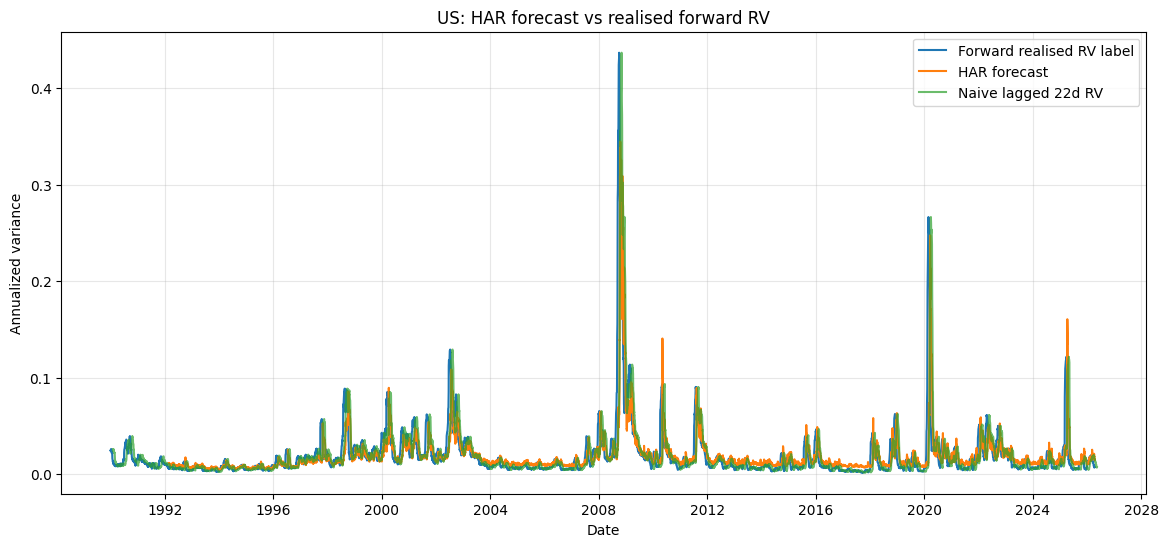

In [10]:
plot_forecast_vs_target(us_har, "US")

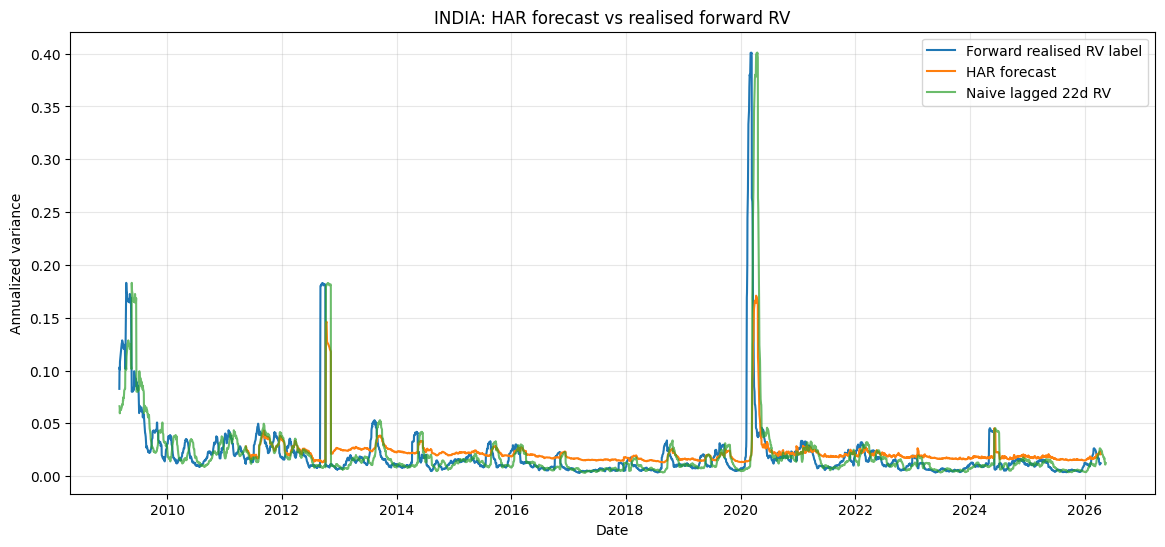

In [11]:
plot_forecast_vs_target(india_har, "INDIA")

In [12]:
def residual_summary(df: pd.DataFrame, market: str) -> pd.DataFrame:
    out = df.copy()
    out["residual"] = (
        out["rv_gk_22d_forward_ann_label"]
        - out["har_rv_gk_22d_forecast_ann"]
    )

    available = out[out["har_forecast_available"].astype(bool)].copy()

    return pd.DataFrame(
        [
            {
                "market": market,
                "n": available["residual"].count(),
                "mean_residual": available["residual"].mean(),
                "median_residual": available["residual"].median(),
                "std_residual": available["residual"].std(),
                "p05_residual": available["residual"].quantile(0.05),
                "p95_residual": available["residual"].quantile(0.95),
                "min_residual": available["residual"].min(),
                "max_residual": available["residual"].max(),
            }
        ]
    )


pd.concat(
    [
        residual_summary(us_har, "US"),
        residual_summary(india_har, "INDIA"),
    ],
    ignore_index=True,
)

,market,n,mean_residual,median_residual,std_residual,p05_residual,p95_residual,min_residual,max_residual
0,US,8590,0.000722,-0.002736,0.024731,-0.013921,0.027675,-0.155724,0.379669
1,INDIA,3638,-0.004300,-0.008408,0.032327,-0.015667,0.011809,-0.136522,0.381568


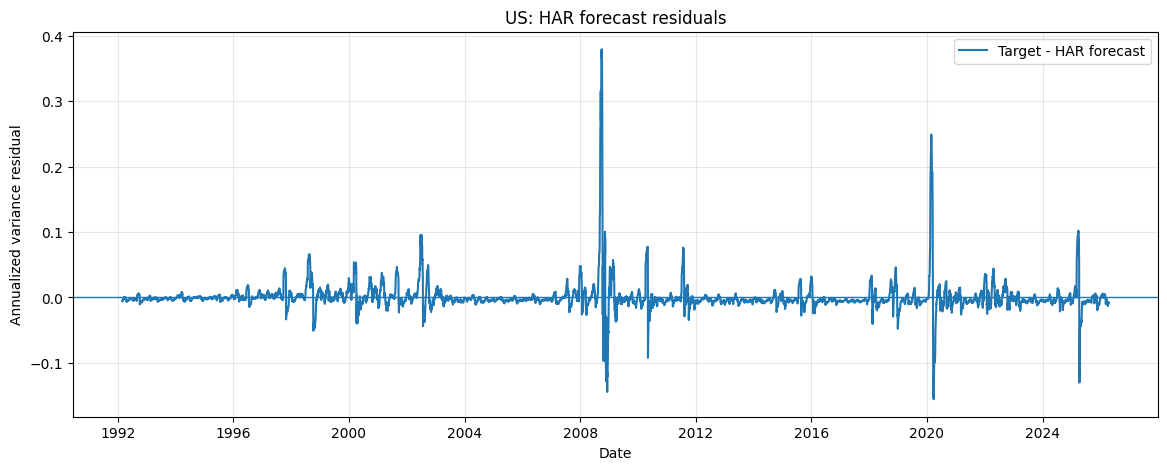

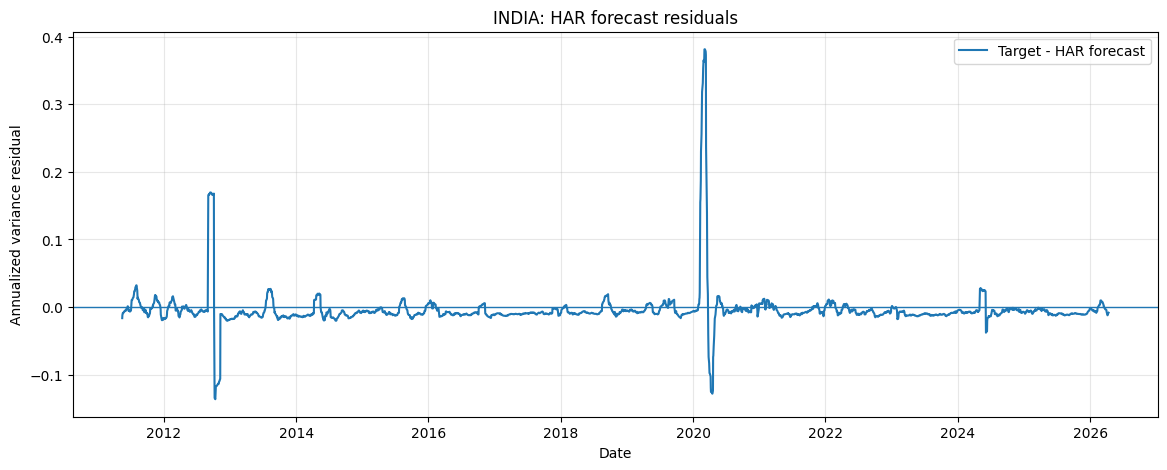

In [13]:
def plot_residuals(df: pd.DataFrame, market: str) -> None:
    plot_df = df.copy()
    plot_df["date"] = pd.to_datetime(plot_df["date"])
    plot_df["residual"] = (
        plot_df["rv_gk_22d_forward_ann_label"]
        - plot_df["har_rv_gk_22d_forecast_ann"]
    )

    available = plot_df[plot_df["har_forecast_available"].astype(bool)]

    plt.figure(figsize=(14, 5))
    plt.plot(available["date"], available["residual"], label="Target - HAR forecast")
    plt.axhline(0.0, linewidth=1)
    plt.title(f"{market}: HAR forecast residuals")
    plt.xlabel("Date")
    plt.ylabel("Annualized variance residual")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


plot_residuals(us_har, "US")
plot_residuals(india_har, "INDIA")

In [14]:
coefficients.head()

,date,market,model_name,train_start_date,train_end_date,n_train,coef_const,coef_har_rv_d_lag1_ann,coef_har_rv_w_lag1_ann,coef_har_rv_m_lag1_ann,se_const,se_har_rv_d_lag1_ann,se_har_rv_w_lag1_ann,se_har_rv_m_lag1_ann,t_const,t_har_rv_d_lag1_ann,t_har_rv_w_lag1_ann,t_har_rv_m_lag1_ann,hac_maxlags,hac_available
0,1992-02-27,US,direct_har_22d_gk_conservative_lag1,1990-02-01,1992-01-24,500,0.006661,0.020877,0.165285,0.314775,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22,False
1,1992-02-28,US,direct_har_22d_gk_conservative_lag1,1990-02-01,1992-01-27,501,0.006654,0.020923,0.165361,0.314904,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22,False
2,1992-03-02,US,direct_har_22d_gk_conservative_lag1,1990-02-01,1992-01-28,502,0.006650,0.020980,0.165354,0.315025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22,False
3,1992-03-03,US,direct_har_22d_gk_conservative_lag1,1990-02-01,1992-01-29,503,0.006639,0.021109,0.165493,0.315192,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22,False
4,1992-03-04,US,direct_har_22d_gk_conservative_lag1,1990-02-01,1992-01-30,504,0.006623,0.019405,0.166544,0.316198,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22,False


In [15]:
if "hac_available" in coefficients.columns:
    hac_summary = (
        coefficients.groupby("market")["hac_available"]
        .agg(["count", "sum", "mean"])
        .rename(columns={"sum": "hac_rows", "mean": "hac_share"})
    )
else:
    hac_summary = pd.DataFrame()

hac_summary

,count,hac_rows,hac_share
market,,,
INDIA,3638,0,0.0
US,8590,0,0.0


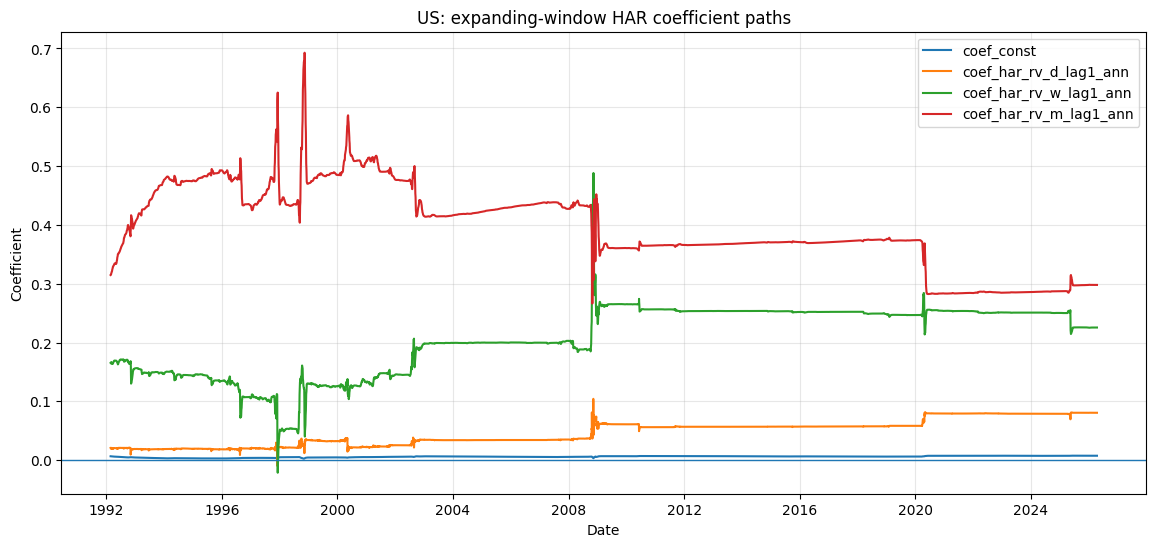

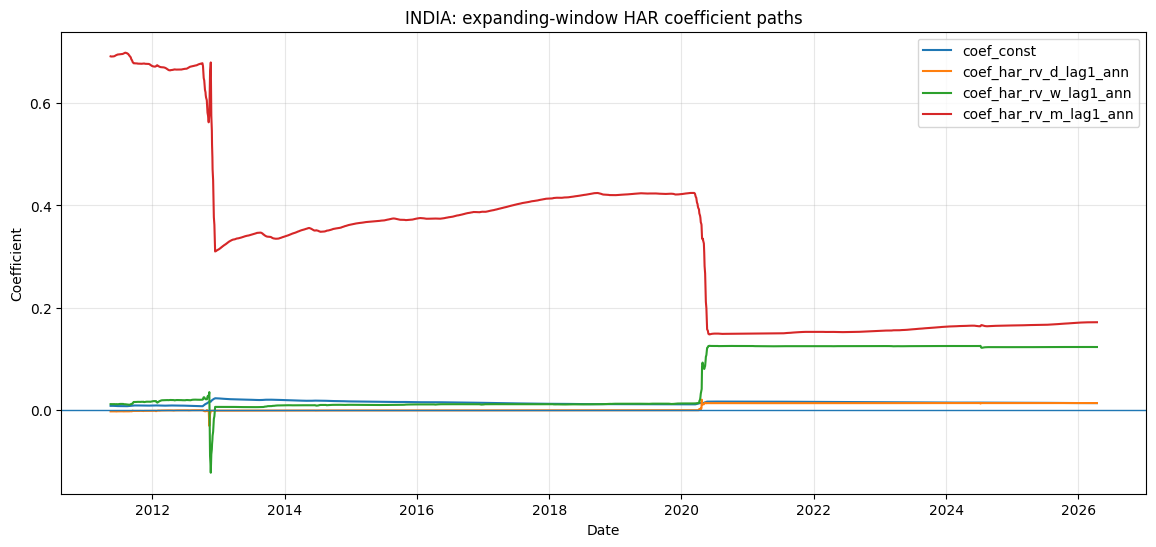

In [16]:
def plot_coefficients(coef_df: pd.DataFrame, market: str) -> None:
    df = coef_df[coef_df["market"] == market].copy()
    df["date"] = pd.to_datetime(df["date"])

    coef_cols = [
        "coef_const",
        "coef_har_rv_d_lag1_ann",
        "coef_har_rv_w_lag1_ann",
        "coef_har_rv_m_lag1_ann",
    ]

    plt.figure(figsize=(14, 6))

    for col in coef_cols:
        if col in df.columns:
            plt.plot(df["date"], df[col], label=col)

    plt.axhline(0.0, linewidth=1)
    plt.title(f"{market}: expanding-window HAR coefficient paths")
    plt.xlabel("Date")
    plt.ylabel("Coefficient")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


plot_coefficients(coefficients, "US")
plot_coefficients(coefficients, "INDIA")

In [18]:
def check_har_vrp_validity(df: pd.DataFrame, market: str) -> pd.DataFrame:
    out = df.copy()

    unavailable = ~out["har_forecast_available"].astype(bool)
    bad = unavailable & out["vrp_har_gk"].notna()

    return pd.DataFrame(
        [
            {
                "market": market,
                "rows": len(out),
                "available_forecasts": int(out["har_forecast_available"].sum()),
                "bad_unavailable_vrp_har_rows": int(bad.sum()),
                "vrp_har_non_null": int(out["vrp_har_gk"].notna().sum()),
            }
        ]
    )


pd.concat(
    [
        check_har_vrp_validity(us_vrp_har, "US"),
        check_har_vrp_validity(india_vrp_har, "INDIA"),
    ],
    ignore_index=True,
)

,market,rows,available_forecasts,bad_unavailable_vrp_har_rows,vrp_har_non_null
0,US,9156,8590,0,8590
1,INDIA,4204,3638,0,3638


In [19]:
vrp_cols = [
    "iv_ann",
    "vrp_backward_gk",
    "vrp_forward_expost_gk_label",
    "har_rv_gk_22d_forecast_ann",
    "vrp_har_gk",
]

def summarize_vrp(df: pd.DataFrame, market: str) -> pd.DataFrame:
    rows = []

    for col in vrp_cols:
        if col not in df.columns:
            continue

        values = pd.to_numeric(df[col], errors="coerce")
        rows.append(
            {
                "market": market,
                "column": col,
                "count": values.count(),
                "mean": values.mean(),
                "median": values.median(),
                "std": values.std(),
                "p05": values.quantile(0.05),
                "p95": values.quantile(0.95),
                "positive_share": (values.dropna() > 0).mean(),
            }
        )

    return pd.DataFrame(rows)


pd.concat(
    [
        summarize_vrp(us_vrp_har, "US"),
        summarize_vrp(india_vrp_har, "INDIA"),
    ],
    ignore_index=True,
)

,market,column,count,mean,median,std,p05,p95,positive_share
0,US,iv_ann,9156,0.043885,0.031046,0.045812,0.013064,0.108785,1.000000
1,US,vrp_backward_gk,9134,0.024738,0.018370,0.026066,0.006242,0.064597,0.985877
2,US,vrp_forward_expost_gk_label,9134,0.024792,0.018536,0.034799,0.000406,0.072498,0.950843
3,US,har_rv_gk_22d_forecast_ann,8590,0.018735,0.013032,0.022353,0.006872,0.046027,1.000000
4,US,vrp_har_gk,8590,0.025154,0.016754,0.029359,0.003587,0.072456,0.997905
5,INDIA,iv_ann,4204,0.040477,0.028107,0.044404,0.012928,0.102381,1.000000
6,INDIA,vrp_backward_gk,4203,0.019613,0.014540,0.028843,0.002834,0.056260,0.973352
7,INDIA,vrp_forward_expost_gk_label,4182,0.019925,0.014830,0.040096,-0.000315,0.067493,0.946915
8,INDIA,har_rv_gk_22d_forecast_ann,3638,0.021930,0.019416,0.014306,0.014679,0.031165,1.000000
9,INDIA,vrp_har_gk,3638,0.012003,0.006113,0.029134,-0.004616,0.047702,0.753711


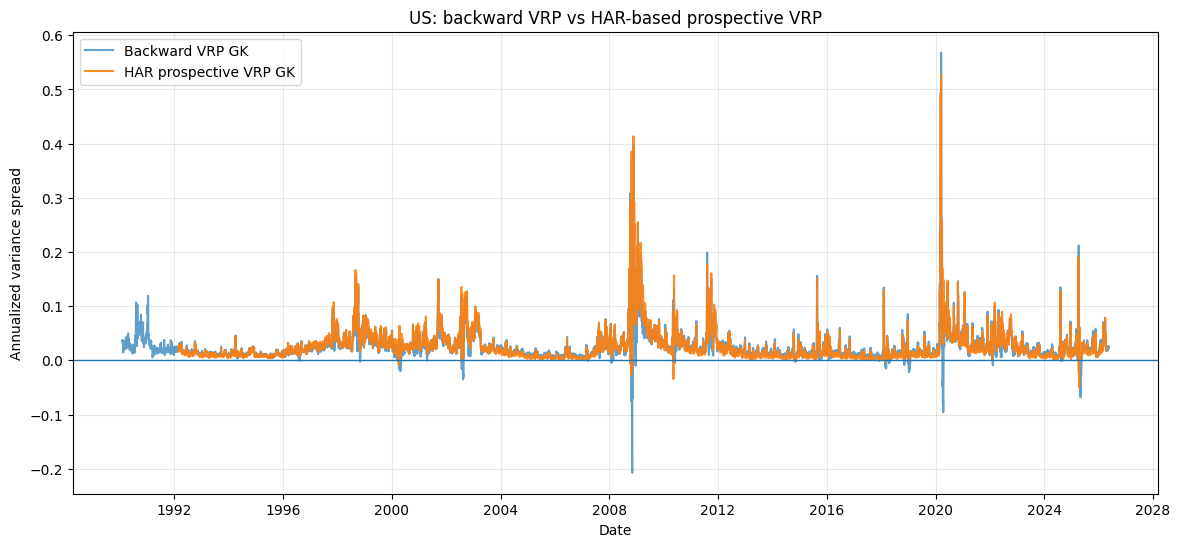

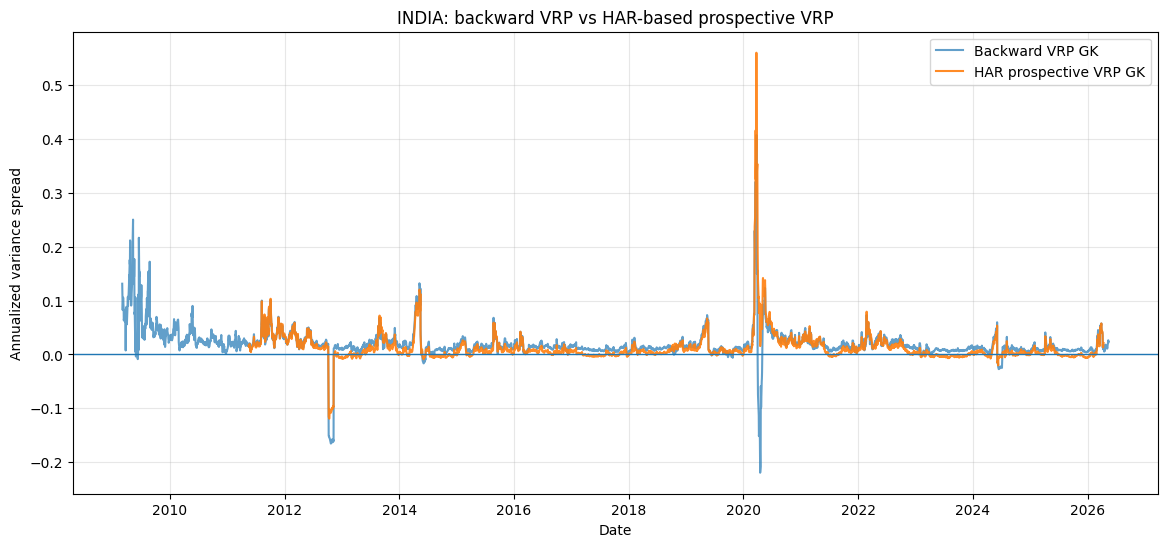

In [20]:
def plot_vrp_comparison(df: pd.DataFrame, market: str) -> None:
    plot_df = df.copy()
    plot_df["date"] = pd.to_datetime(plot_df["date"])

    plt.figure(figsize=(14, 6))

    if "vrp_backward_gk" in plot_df.columns:
        plt.plot(
            plot_df["date"],
            plot_df["vrp_backward_gk"],
            label="Backward VRP GK",
            alpha=0.7,
        )

    plt.plot(
        plot_df["date"],
        plot_df["vrp_har_gk"],
        label="HAR prospective VRP GK",
        alpha=0.9,
    )

    plt.axhline(0.0, linewidth=1)
    plt.title(f"{market}: backward VRP vs HAR-based prospective VRP")
    plt.xlabel("Date")
    plt.ylabel("Annualized variance spread")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


plot_vrp_comparison(us_vrp_har, "US")
plot_vrp_comparison(india_vrp_har, "INDIA")

In [21]:
display_cols = [
    "market",
    "forecast_col",
    "n_obs",
    "rmse",
    "mae",
    "qlike",
    "bias",
    "correlation",
    "directional_accuracy_vs_baseline",
]

accuracy[display_cols].sort_values(["market", "qlike"])

,market,forecast_col,n_obs,rmse,mae,qlike,bias,correlation,directional_accuracy_vs_baseline
4,INDIA,har_rv_gk_22d_forecast_ann,3638,0.032608,0.013099,0.364206,0.004300,0.139127,0.575316
6,INDIA,expanding_mean_forward_rv_baseline,4137,0.033318,0.018245,0.392270,0.010922,0.240600,0.556684
5,INDIA,naive_lagged_22d_rv_ann,4181,0.038402,0.012560,0.398283,0.000267,0.318356,NaN
7,INDIA,rolling_mean_forward_rv_baseline,4137,0.033198,0.015921,0.419907,0.007168,0.226978,0.589316
0,US,har_rv_gk_22d_forecast_ann,8590,0.024740,0.010020,0.226052,-0.000722,0.616259,0.614552
1,US,naive_lagged_22d_rv_ann,9112,0.027690,0.010778,0.289956,0.000026,0.582927,NaN
2,US,expanding_mean_forward_rv_baseline,9089,0.030495,0.014070,0.475012,-0.002212,0.051463,0.586093
3,US,rolling_mean_forward_rv_baseline,9089,0.031071,0.014829,0.510730,-0.000087,0.100783,0.581692


## Interpretation notes

### US

HAR is compared against:
- naive lagged 22-day RV
- expanding historical forward-RV mean
- rolling historical forward-RV mean

Report only what the table supports. If HAR has lower RMSE, MAE, and QLIKE, state that it improves over baselines on those metrics.

### India

India should be interpreted separately. If HAR improves RMSE and QLIKE but not MAE or correlation, state that it improves variance-forecast loss metrics but does not dominate all naive baselines.

### No-lookahead status

The audit requires:

`max_training_target_end_date < forecast_date`

for every available forecast row.

### HAR-VRP validity

`vrp_har_gk` is only valid when:

`har_forecast_available == True`

Unavailable forecast rows must have null `vrp_har_gk`.

In [22]:
print("Notebook inspection complete.")
print("No models were fitted in this notebook.")
print("No production outputs were written in this notebook.")

Notebook inspection complete.
No models were fitted in this notebook.
No production outputs were written in this notebook.
